# Week 6 — Feature Engineering

Building on the baseline feature set used in `04_testing_models.ipynb`, this notebook adds three engineered features and re-trains the same set of models to see whether they help:

1. **BedBathRatio** — bedrooms per bathroom, a simple layout/quality proxy.
2. **PropertyAge** — age of the property in years at time of sale (`CloseDate` year − `YearBuilt`).
3. **SchoolDistrict / SchoolDistrict_MeanPrice** — a more detailed regional feature built by spatially joining each property's coordinates against the [California School District Areas 2024-25](https://data.ca.gov/dataset/california-school-district-areas-2024-25/resource/7dfaf005-58eb-45db-93b1-7aff091b2172) boundaries, then target-encoding the resulting district as mean `ClosePrice`.

The notebook ends with a table comparing model performance on the old vs. new feature sets.

In [1]:
import sys
print(sys.executable)
print(sys.version)

/home/shasm/idx_exchange_summer/.venv/bin/python
3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]


In [2]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

In [3]:
train = pd.read_csv("basic_train_set.csv")
test = pd.read_csv("basic_test_set.csv")

# Same baseline feature set as 04_testing_models.ipynb, kept around so we can
# train old-vs-new comparisons on identical rows later in this notebook.
old_feature_cols = ['Latitude', 'Longitude', 'LivingArea', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt',
                     'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'MainLevelBedrooms'
                    , 'AssociationFee', 'LotSizeSquareFeet', 'Levels_MultiSplit', 'NumLevels']

print(train.shape, test.shape)

(336198, 98) (10581, 98)


/tmp/ipykernel_5313/438229741.py:1: DtypeWarning: Columns (0: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("basic_train_set.csv")


## Feature 1: Bed/Bath Ratio

Bedrooms per bathroom is a cheap proxy for layout quality/crowding that isn't directly captured by `BedroomsTotal` or `BathroomsTotalInteger` alone. A handful of listings have `BathroomsTotalInteger == 0` (data artifacts), which would produce `inf`; those are treated as missing and filled with the train-set median ratio, computed on train only to avoid leaking test information.

In [4]:
for df in (train, test):
    bath = df['BathroomsTotalInteger'].replace(0, np.nan)
    df['BedBathRatio'] = df['BedroomsTotal'] / bath

train_ratio_median = train['BedBathRatio'].median()
for df in (train, test):
    df['BedBathRatio'] = df['BedBathRatio'].fillna(train_ratio_median)

train['BedBathRatio'].describe()

count    336198.000000
mean          1.384788
std           0.482896
min           0.000000
25%           1.000000
50%           1.333333
75%           1.500000
max           7.000000
Name: BedBathRatio, dtype: float64

## Feature 2: Property Age

Age at time of sale often matters more than raw `YearBuilt` (a 1990-built home sold in 2010 vs. 2023 has a different effective age). Computed as `year(CloseDate) - YearBuilt`, clipped at 0 to absorb the rare new-construction rows where `YearBuilt` is the same year as, or nominally after, `CloseDate`.

In [5]:
for df in (train, test):
    df['PropertyAge'] = pd.to_datetime(df['CloseDate']).dt.year - df['YearBuilt']
    df['PropertyAge'] = df['PropertyAge'].clip(lower=0)

train['PropertyAge'].describe()

count    336198.000000
mean         46.015414
std          25.775732
min           0.000000
25%          27.000000
50%          45.000000
75%          64.000000
max         247.000000
Name: PropertyAge, dtype: float64

## Feature 3: School District Spatial Layer

The dataset already has a `HighSchoolDistrict` column, but it's missing for ~27% of rows and only captures the high-school layer. Instead, we spatially join each property's `(Latitude, Longitude)` against the [CA School District Areas 2024-25](https://data.ca.gov/dataset/california-school-district-areas-2024-25/resource/7dfaf005-58eb-45db-93b1-7aff091b2172) boundary polygons, which is authoritative and covers essentially every property.

A wrinkle: California school districts come in three types — `Unified` (K-12, one district), or split `Elementary` + `High` districts that geographically overlap each other. A point can therefore land inside more than one polygon. We resolve this per property with:

1. If a `Unified` district contains the point, use that district name.
2. Otherwise, combine the `Elementary` and `High` district names it falls in (e.g. `"National Elementary / Sweetwater Union High"`).
3. A tiny number of points don't fall inside any polygon (edge-of-coastline listings, bad lat/long); these are assigned via nearest-polygon lookup instead.

The resulting `SchoolDistrict` category (624 unique districts) is then target-encoded as mean `ClosePrice` per district — the same technique already used for `CountyOrParish_MeanPrice` in `02_preprocessing.ipynb` — fit on train only and applied to test, with unseen/unmatched districts falling back to the train-set global mean.

In [6]:
# Download and unzip the CA School District Areas 2024-25 shapefile if we don't
# already have a local copy (~11MB zipped).
SHAPEFILE_DIR = "school_districts"
SHAPEFILE_PATH = os.path.join(SHAPEFILE_DIR, "DistrictAreas2425.shp")
SHAPEFILE_URL = "https://gis.data.ca.gov/api/download/v1/items/b0e3b936426a47ce9d9a2e77e2bb86cc/shapefile?layers=0"

if not os.path.exists(SHAPEFILE_PATH):
    os.makedirs(SHAPEFILE_DIR, exist_ok=True)
    zip_path = os.path.join(SHAPEFILE_DIR, "ca_school_districts.zip")
    urllib.request.urlretrieve(SHAPEFILE_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(SHAPEFILE_DIR)

districts = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)
districts = districts[['DistrictNa', 'DistrictTy', 'geometry']]
print(f"{len(districts)} district polygons loaded")
districts['DistrictTy'].value_counts()

937 district polygons loaded


DistrictTy
Elementary    516
Unified       345
High           76
Name: count, dtype: int64

In [7]:
def spatial_join_districts(df, districts):
    """Assign each row a SchoolDistrict label via point-in-polygon join.

    Prefers a Unified district; otherwise combines Elementary + High district
    names. Points that miss every polygon fall back to nearest-polygon lookup.
    """
    pts = gpd.GeoDataFrame(
        df[['Latitude', 'Longitude']].copy(),
        geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
        crs='EPSG:4326',
    )
    joined = gpd.sjoin(pts, districts, how='left', predicate='within')[['DistrictNa', 'DistrictTy']]

    missing_idx = joined[joined['DistrictNa'].isna()].index.unique()
    if len(missing_idx) > 0:
        # sjoin_nearest needs a projected (planar) CRS for correct distances.
        pts_3857 = pts.to_crs(epsg=3857)
        districts_3857 = districts.to_crs(epsg=3857)
        nearest = gpd.sjoin_nearest(pts_3857.loc[missing_idx], districts_3857, how='left')[['DistrictNa', 'DistrictTy']]
        joined = pd.concat([joined.drop(index=missing_idx), nearest])

    def pick(group):
        types = dict(zip(group['DistrictTy'], group['DistrictNa']))
        if 'Unified' in types:
            return types['Unified']
        parts = [types[t] for t in ('Elementary', 'High') if t in types]
        if parts:
            return ' / '.join(parts)
        return next(iter(types.values()), np.nan)

    result = joined.groupby(level=0).apply(pick)
    result.index = df.index
    return result

train['SchoolDistrict'] = spatial_join_districts(train, districts)
test['SchoolDistrict'] = spatial_join_districts(test, districts)

print(f"train SchoolDistrict unmatched: {train['SchoolDistrict'].isna().sum()} / {len(train)}")
print(f"test SchoolDistrict unmatched:  {test['SchoolDistrict'].isna().sum()} / {len(test)}")
print(f"unique districts (train): {train['SchoolDistrict'].nunique()}")
print()
print("For comparison, the old HighSchoolDistrict field:")
print(f"train HighSchoolDistrict missing: {train['HighSchoolDistrict'].isna().sum()} / {len(train)}")

train SchoolDistrict unmatched: 0 / 336198
test SchoolDistrict unmatched:  0 / 10581
unique districts (train): 684

For comparison, the old HighSchoolDistrict field:
train HighSchoolDistrict missing: 89522 / 336198


In [8]:
# Target-encode SchoolDistrict as mean ClosePrice, fit on train only (matches
# the CountyOrParish_MeanPrice pattern from 02_preprocessing.ipynb). Unseen or
# unmatched districts (including the 2 bad-coordinate rows above) fall back to
# the train-set global mean.
district_means = train.groupby('SchoolDistrict')['ClosePrice'].mean()
global_mean = train['ClosePrice'].mean()

train['SchoolDistrict_MeanPrice'] = train['SchoolDistrict'].map(district_means).fillna(global_mean)
test['SchoolDistrict_MeanPrice'] = test['SchoolDistrict'].map(district_means).fillna(global_mean)

new_feature_cols = old_feature_cols + ['BedBathRatio', 'PropertyAge', 'SchoolDistrict_MeanPrice']
train[['SchoolDistrict', 'SchoolDistrict_MeanPrice']].head()

,SchoolDistrict,SchoolDistrict_MeanPrice
0,Los Angeles Unified,1.120451e+06
1,Adelanto Elementary / Victor Valley Union High,4.113829e+05
2,San Jacinto Unified,4.453676e+05
3,Compton Unified,6.299472e+05
4,Lake Elsinore Unified,6.105985e+05


## Save Engineered Datasets

In [9]:
train.to_csv("engineered_train_set.csv", index=False)
test.to_csv("engineered_test_set.csv", index=False)
print("saved engineered_train_set.csv and engineered_test_set.csv")

saved engineered_train_set.csv and engineered_test_set.csv


## Feature 4: Month Sine/Cosine (Seasonality)

`CloseMonth` exists in the raw data as a `YYYY-MM` string, which is really a train-set-specific
timestamp, not a reusable seasonality signal, and using it as an ordinal would wrongly imply
December (12) is "further" from January (1) than June is. Per the seasonality guidance, month
of sale (from `CloseDate`) is instead encoded cyclically as `sin`/`cos` pairs so December and
January end up adjacent in feature space, same as any other consecutive months.

In [10]:
for df in (train, test):
    close_month = pd.to_datetime(df['CloseDate']).dt.month
    df['CloseMonth_sin'] = np.sin(2 * np.pi * close_month / 12)
    df['CloseMonth_cos'] = np.cos(2 * np.pi * close_month / 12)

train[['CloseMonth_sin', 'CloseMonth_cos']].describe()

,CloseMonth_sin,CloseMonth_cos
count,3.361980e+05,3.361980e+05
mean,-1.286444e-02,-5.683275e-02
std,7.146069e-01,6.970972e-01
min,-1.000000e+00,-1.000000e+00
25%,-8.660254e-01,-8.660254e-01
50%,-2.449294e-16,-1.836970e-16
75%,8.660254e-01,5.000000e-01
max,1.000000e+00,1.000000e+00


## Feature 5: Distance to Nearest Major CA CBD

Raw `Latitude`/`Longitude` encode location but require a model to learn urban-proximity
effects (prices generally fall off with distance from job centers) implicitly and
nonlinearly. We compute the great-circle (haversine) distance from each property to each of
six major California CBDs — Los Angeles, San Francisco, San Diego, Sacramento, San Jose,
Fresno — and take the minimum, giving a single monotonic proximity-to-urban-core signal that
linear models can use directly. Purely geometric (no fitting), so it's computed identically
for train and test with no leakage risk.

In [11]:
CBD_COORDS = {
    'Los Angeles': (34.0407, -118.2468),
    'San Francisco': (37.7749, -122.4194),
    'San Diego': (32.7157, -117.1611),
    'Sacramento': (38.5816, -121.4944),
    'San Jose': (37.3382, -121.8863),
    'Fresno': (36.7378, -119.7871),
}


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))


for df in (train, test):
    dists_to_cbds = np.column_stack([
        haversine_km(df['Latitude'], df['Longitude'], lat, lon)
        for lat, lon in CBD_COORDS.values()
    ])
    df['DistanceToNearestCBD_km'] = dists_to_cbds.min(axis=1)

train['DistanceToNearestCBD_km'].describe()

count    336198.000000
mean         56.620089
std          43.350404
min           0.002239
25%          22.652673
50%          44.749253
75%          81.859077
max         422.652483
Name: DistanceToNearestCBD_km, dtype: float64

## Save Engineered Datasets (v2 — adds seasonality + CBD distance)

`engineered_train_set.csv` / `engineered_test_set.csv` above stay as the original 3-feature
set. This second pair adds the two features below on top and is saved separately so both
versions remain reproducible independently.

In [12]:
newest_feature_cols = new_feature_cols + ['CloseMonth_sin', 'CloseMonth_cos', 'DistanceToNearestCBD_km']

train.to_csv("engineered_train_set_v2.csv", index=False)
test.to_csv("engineered_test_set_v2.csv", index=False)
print("saved engineered_train_set_v2.csv and engineered_test_set_v2.csv")
print(f"newest_feature_cols ({len(newest_feature_cols)}): {newest_feature_cols}")

saved engineered_train_set_v2.csv and engineered_test_set_v2.csv
newest_feature_cols (21): ['Latitude', 'Longitude', 'LivingArea', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'AssociationFee', 'LotSizeSquareFeet', 'Levels_MultiSplit', 'NumLevels', 'BedBathRatio', 'PropertyAge', 'SchoolDistrict_MeanPrice', 'CloseMonth_sin', 'CloseMonth_cos', 'DistanceToNearestCBD_km']


# Re-train Models: Old vs New Feature Set

Same models and hyperparameters as `04_testing_models.ipynb` (Linear Regression, Decision Tree, Random Forest, each with a log-target variant), trained once on `old_feature_cols` (16 features) and once on `new_feature_cols` (19 features = old + BedBathRatio + PropertyAge + SchoolDistrict_MeanPrice).

In [ ]:
y_train = train['ClosePrice']
y_test = test['ClosePrice']
y_train_log = np.log1p(y_train)


def evaluate_feature_set(feature_cols, label):
    """Train the same 6 model configs as 04_testing_models.ipynb on feature_cols,
    returning (results_rows, fitted_random_forest) so we can inspect importances."""
    X_train = train[feature_cols]
    X_test = test[feature_cols]

    rows = []

    def add_row(name, preds):
        preds = np.asarray(preds)
        rows.append((
            label, name,
            r2_score(y_test, preds),
            mean_absolute_error(y_test, preds),
            mean_absolute_percentage_error(y_test, preds),
        ))

    lr = LinearRegression().fit(X_train, y_train)
    add_row('Linear Regression', lr.predict(X_test))

    lr_log = LinearRegression().fit(X_train, y_train_log)
    add_row('Linear Regression (log)', np.expm1(lr_log.predict(X_test)))

    dt = DecisionTreeRegressor(max_depth=10, random_state=42).fit(X_train, y_train)
    add_row('Decision Tree', dt.predict(X_test))

    dt_log = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42).fit(X_train, y_train_log)
    add_row('Decision Tree (log)', np.expm1(dt_log.predict(X_test)))

    rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42).fit(X_train, y_train)
    add_row('Random Forest', rf.predict(X_test))

    rf_log = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42).fit(X_train, y_train_log)
    add_row('Random Forest (log)', np.expm1(rf_log.predict(X_test)))

    return rows, rf


old_rows, rf_old = evaluate_feature_set(old_feature_cols, 'Old (16 features)')
new_rows, rf_new = evaluate_feature_set(new_feature_cols, 'New (19 features)')

print("done training both feature sets")

## Comparison Table: Old vs New Feature Set

In [ ]:
results = pd.DataFrame(old_rows + new_rows, columns=['Feature Set', 'Model', 'R2', 'MAE', 'MAPE'])

comparison = results.pivot(index='Model', columns='Feature Set', values=['R2', 'MAE', 'MAPE'])
comparison = comparison.reindex(['Linear Regression', 'Linear Regression (log)', 'Decision Tree',
                                  'Decision Tree (log)', 'Random Forest', 'Random Forest (log)'])
comparison

R2                                 MAE  \
Feature Set             New (19 features) Old (16 features) New (19 features)   
Model                                                                           
Linear Regression                0.678496          0.287899     236870.856371   
Linear Regression (log)          0.565928          0.199745     247371.214358   
Decision Tree                    0.817158          0.790767     165791.841634   
Decision Tree (log)              0.794601          0.720178     171523.438990   
Random Forest                    0.893751          0.891913     123052.617425   
Random Forest (log)              0.881982          0.871660     127808.175538   

                                                       MAPE                    
Feature Set             Old (16 features) New (19 features) Old (16 features)  
Model                                                                          
Linear Regression           367897.669038          0.258663          0.433046  
Linear Regression (log)     376840.473776          0.239685          0.394819  
Decision Tree               183612.588652          0.166521          0.190357  
Decision Tree (log)         202299.599506          0.165146          0.193607  
Random Forest               125404.083704          0.122705          0.126752  
Random Forest (log)         133580.449660          0.122700          0.127735

## Feature Importance (New Feature Set, Random Forest)

SchoolDistrict_MeanPrice    0.470915
LivingArea                  0.317659
Longitude                   0.048480
Latitude                    0.045133
AssociationFee              0.027317
BedroomsTotal               0.022453
YearBuilt                   0.013486
PropertyAge                 0.011302
LotSizeSquareFeet           0.008064
LotSizeArea                 0.007913
LotSizeAcres                0.007633
BedBathRatio                0.006843
MainLevelBedrooms           0.003693
ParkingTotal                0.003049
BathroomsTotalInteger       0.002209
NumLevels                   0.002147
Stories                     0.001427
Levels_MultiSplit           0.000277
dtype: float64


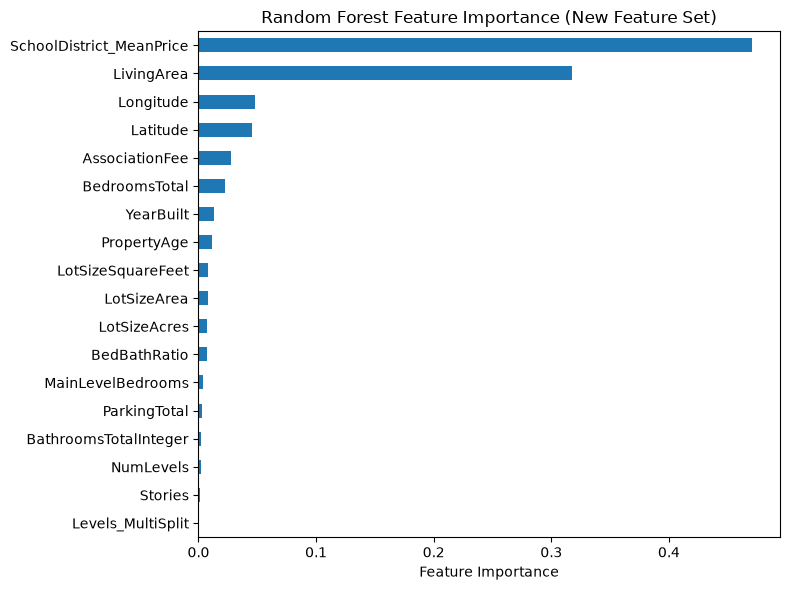

In [ ]:
new_importances = pd.Series(rf_new.feature_importances_, index=new_feature_cols).sort_values(ascending=False)
print(new_importances)

plt.figure(figsize=(8, 6))
new_importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (New Feature Set)')
plt.tight_layout()
plt.show()

# Notes

- **Linear Regression benefits the most** from the new feature set (R² roughly triples). It has no way to capture nonlinear geographic effects from raw `Latitude`/`Longitude` on its own, so `SchoolDistrict_MeanPrice` — a single linear, price-informed regional signal — closes a lot of that gap.
- **Decision Tree** also improves meaningfully, for the same reason: it needs many splits to approximate the geographic pattern that raw lat/long encodes, and the pre-aggregated district signal is more accessible in fewer splits.
- **Random Forest is roughly flat** between the two feature sets (non-log slightly down, log variant slightly up). This makes sense — with 100 trees of depth 15, RF can already carve up `Latitude`/`Longitude` into fine-grained regions on its own, so `SchoolDistrict_MeanPrice` is largely redundant information for it, and by far the dominant feature in its importance ranking (`SchoolDistrict_MeanPrice` > `LivingArea` > lat/long) — it's leaning on the new feature but not gaining much accuracy from it since it was already extracting a similar signal from coordinates.
- `SchoolDistrict_MeanPrice` also gives full coverage (near-zero missing rows) vs. ~27% missing for the old `HighSchoolDistrict` field, which matters for models/pipelines that can't handle missing categoricals natively.
- `BedBathRatio` and `PropertyAge` contribute only marginally to Random Forest's importance ranking individually, but they're cheap to compute and help the weaker linear/tree models pick up on layout and depreciation effects that raw bed/bath counts and year-built don't directly express.